In [2]:
import pandas as pd
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/labeled_prs_v2.csv")

In [3]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = st_model.encode(df["title"].fillna("").tolist(), show_progress_bar=True)

numeric = ["additions", "deletions", "changed_files", "commits",
           "comments", "review_comments", "num_files",
           "author_past_prs", "author_past_bug_rate", "is_first_pr"]

emb_small = PCA(n_components=30, random_state=42).fit_transform(embeddings)
X = np.hstack([df[numeric].values, emb_small])
y = df["label"].values

# named columns make SHAP plots readable
feature_names = numeric + [f"title_emb_{i}" for i in range(30)]
X_df = pd.DataFrame(X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

model = joblib.load("../models/best_model.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [4]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
# for binary RF, shap returns values per class — take class 1 (buggy)
sv = shap_values[:, :, 1] if np.array(shap_values).ndim == 3 else shap_values
print(np.array(sv).shape)

Matplotlib is building the font cache; this may take a moment.


(100, 40)


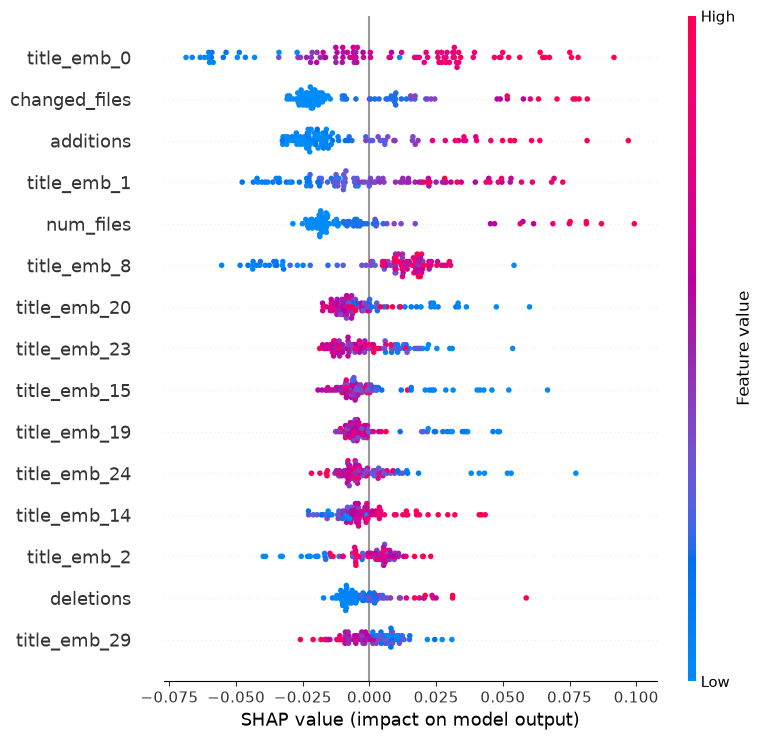

In [5]:
shap.summary_plot(sv, X_test, max_display=15)

In [6]:
def explain_pr(i):
    """Top 3 reasons why test-set PR #i got its risk score."""
    risk = model.predict_proba(X_test.iloc[[i]])[0, 1]
    contributions = pd.Series(sv[i], index=feature_names)
    top3 = contributions.abs().sort_values(ascending=False).head(3)

    print(f"Risk score: {risk:.0%}")
    for feat in top3.index:
        direction = "↑ raises risk" if contributions[feat] > 0 else "↓ lowers risk"
        print(f"  {feat} = {X_test.iloc[i][feat]:.1f}  {direction}")

explain_pr(0)

Risk score: 52%
  title_emb_1 = 0.2  ↑ raises risk
  title_emb_19 = -0.1  ↑ raises risk
  additions = 1.0  ↓ lowers risk


c:\Users\Hp\AutoDebugAI\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
